In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc
import scipy.stats as stats
from scipy.signal import find_peaks
from statsmodels.stats.anova import AnovaRM

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_100226/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
data = processed_data_20cm

In [33]:
freqs = list(data.keys())
volts = [0.1, 0.2, 0.25, 0.3]
cond = [None, 'p005']

def perform_AnovaRM(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    results = []
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Extracting free surface elevation data
            eta_P0 = df['P_0'].dropna().values * -1
            eta_P3 = df['P_3'].dropna().values * -1

            # Detect peaks in the free surface elevation data
            threshold = np.sqrt(2)*np.std(eta_P0) - 0.001
            peak_idx_P0 = find_peaks(eta_P0, threshold)[0]
            peak_idx_P3 = find_peaks(eta_P3, threshold)[0]

            # Keep positive amplitudes only
            amp_P0 = []
            for idx in peak_idx_P0:
                amp_P0.append(eta_P0[idx])
            amp_P3 = []
            for idx in peak_idx_P3:
                amp_P3.append(eta_P3[idx])

            amp_P0 = [amp for amp in amp_P0 if amp > 0]
            amp_P3 = [amp for amp in amp_P3 if amp > 0]

            # Need same number of peaks for both conditions to perform ANOVA
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            subjects = np.arange(1, n + 1)

            df_long = pd.DataFrame({
            'subject': np.concatenate([subjects, subjects]),
            'probe':   np.concatenate([np.repeat('P_0', n), np.repeat('P_3', n)]),
            'amplitude': np.concatenate([amp_P0, amp_P3])})

            print(f"ANOVA for freq={freq} Hz, voltage={v} V, condition={cond}, run={r}:")

            aov = AnovaRM(
                data=df_long,
                depvar='amplitude',
                subject='subject',
                within=['probe']
            ).fit()

            print(aov.summary())  

            results.append({
                'freq': freq,
                'voltage': v,
                'condition': cond,
                'run': r,
                'anova_table': aov.anova_table
            })
            if cond == 'p005':
                config = '5 cm plates'
            else:
                config = 'no plates'
            plt.hist(amp_P0, bins=10, alpha=0.5, color='C0', label='P_0')
            plt.vlines(np.mean(amp_P0), ymin=0, ymax=plt.gca().get_ylim()[1], colors='C0', linestyles='dashed', label='Mean P_0')
            plt.hist(amp_P3, bins=10,alpha=0.5, color='C1', label='P_3')
            plt.vlines(np.mean(amp_P3), ymin=0, ymax=plt.gca().get_ylim()[1], colors='C1', linestyles='dashed', label='Mean P_3')
            plt.xlabel('Amplitude (m)')
            plt.ylabel('Frequency')
            plt.title(f'Distribution of Free Surface Amplitudes \n f={freq} Hz, V={v} V, {config}, {r}')
            plt.legend(title =f'p-value={aov.anova_table.loc["probe", "Pr > F"]:.3f}', ncol=2)
            plt.show()

    return results, amp_P0, amp_P3   

ANOVA for freq=1.5 Hz, voltage=0.1 V, condition=p005, run=R1:
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
probe 18.1611 1.0000 87.0000 0.0001



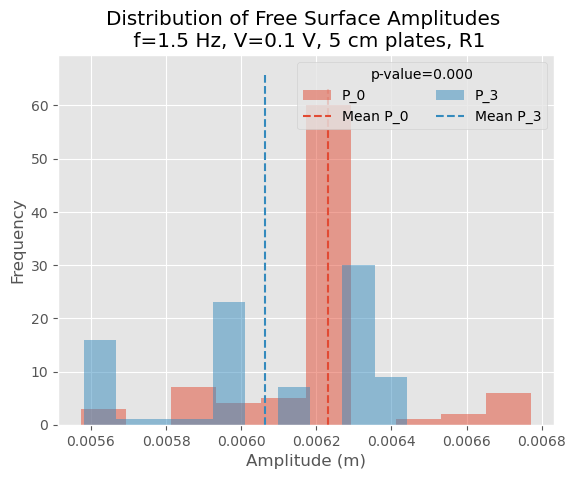

ANOVA for freq=1.5 Hz, voltage=0.1 V, condition=p005, run=R2:
               Anova
      F Value Num DF  Den DF  Pr > F
------------------------------------
probe 32.0451 1.0000 103.0000 0.0000



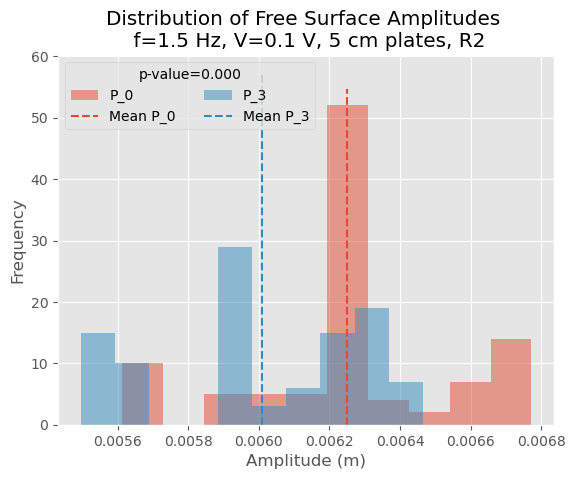

ANOVA for freq=1.5 Hz, voltage=0.1 V, condition=p005, run=R3:
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
probe 24.9186 1.0000 90.0000 0.0000



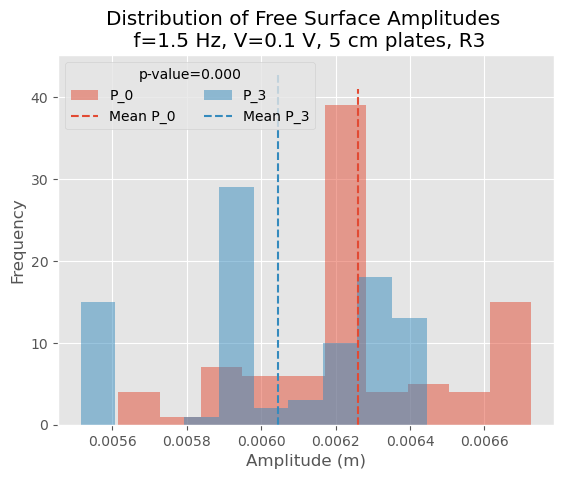

ANOVA for freq=1.5 Hz, voltage=0.2 V, condition=p005, run=R1:
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
probe  7.7276 1.0000 48.0000 0.0077



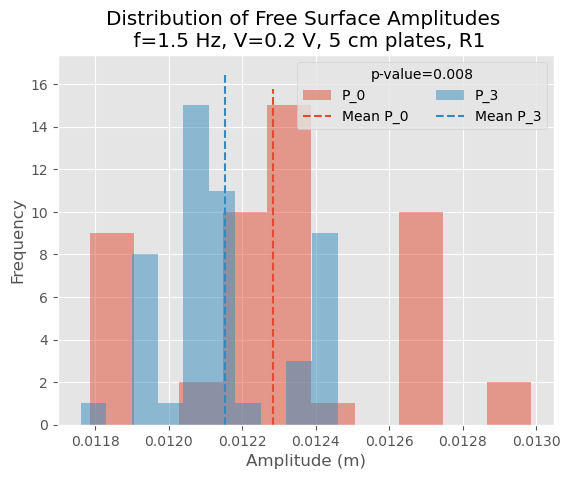

ANOVA for freq=1.5 Hz, voltage=0.2 V, condition=p005, run=R2:
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
probe 55.9014 1.0000 45.0000 0.0000



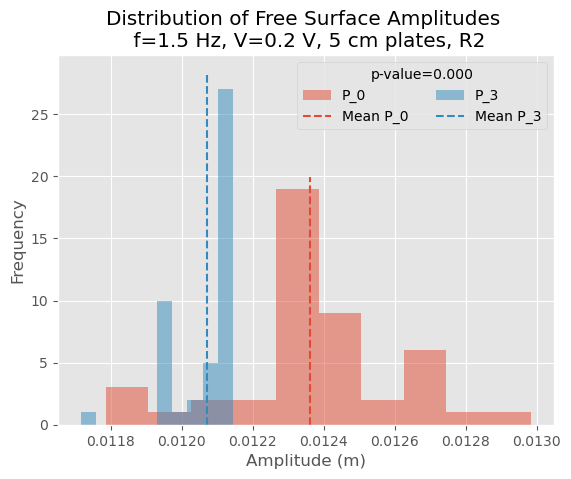

ANOVA for freq=1.5 Hz, voltage=0.2 V, condition=p005, run=R3:
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
probe 11.7441 1.0000 33.0000 0.0017



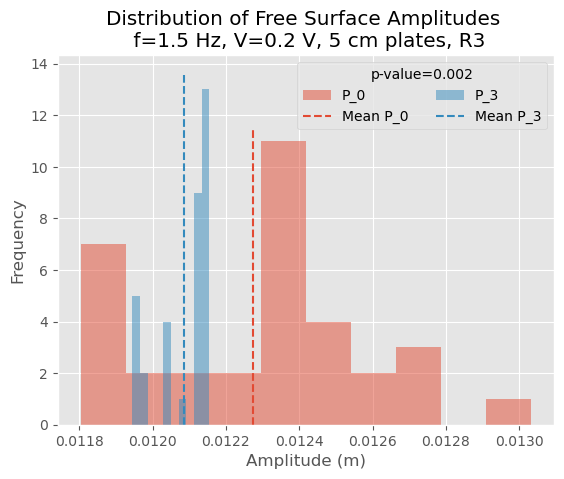

ANOVA for freq=1.5 Hz, voltage=0.3 V, condition=p005, run=R1:
               Anova
      F Value  Num DF  Den DF Pr > F
------------------------------------
probe 474.1538 1.0000 52.0000 0.0000



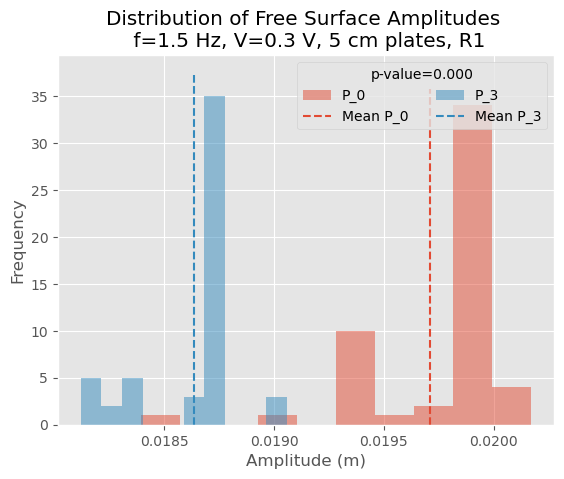

ANOVA for freq=1.5 Hz, voltage=0.3 V, condition=p005, run=R2:
               Anova
      F Value  Num DF  Den DF Pr > F
------------------------------------
probe 532.4963 1.0000 54.0000 0.0000



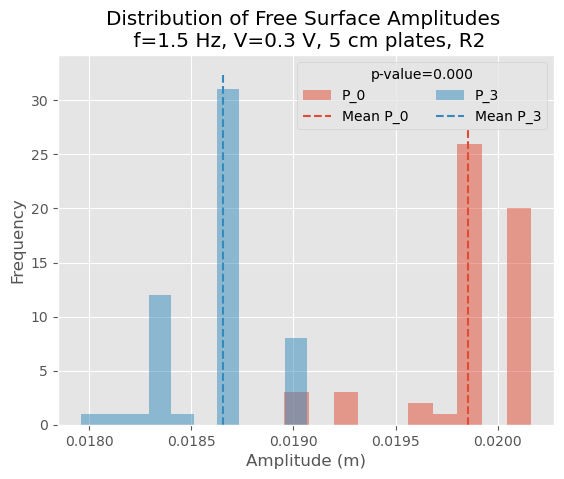

ANOVA for freq=1.5 Hz, voltage=0.3 V, condition=p005, run=R3:
               Anova
      F Value  Num DF  Den DF Pr > F
------------------------------------
probe 841.0268 1.0000 60.0000 0.0000



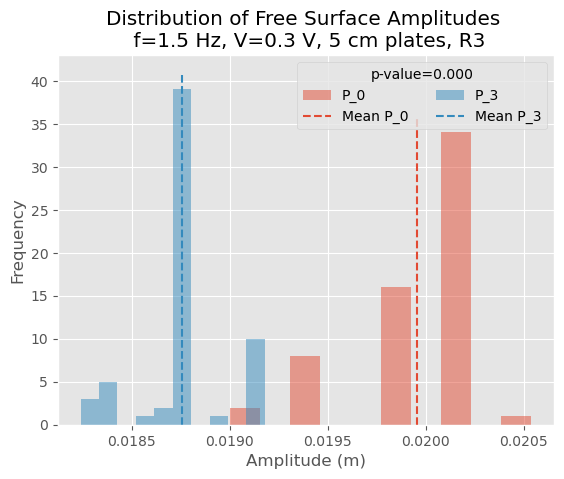

In [34]:
anova_f11, amp_P0, amp_P3 = perform_AnovaRM(1.5, 'p005')